/mnt/D06A89C26A89A5B6/Forage/JPMorgan_Quantitative_research/task1.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


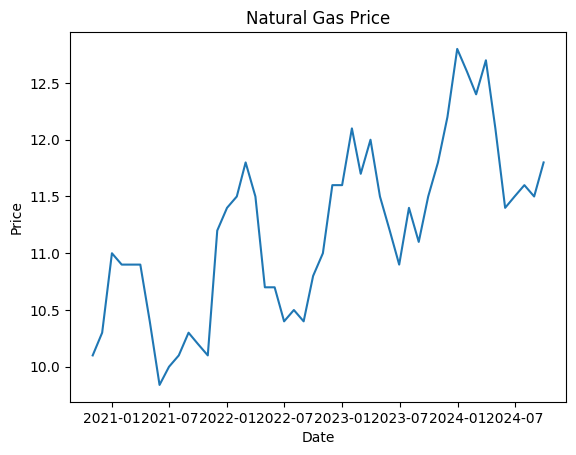

10.98
44.79


In [8]:
import pandas as pd
from task1 import get_price

In [6]:
df = pd.read_csv('data/Nat_Gas_fortask2.csv')
print(df.head())
print(df.dtypes)
print(df.describe())
print(df.info())

      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9
Dates         str
Prices    float64
dtype: object
          Prices
count  48.000000
mean   11.207083
std     0.757897
min     9.840000
25%    10.650000
50%    11.300000
75%    11.625000
max    12.800000
<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     str    
 1   Prices  48 non-null     float64
dtypes: float64(1), str(1)
memory usage: 900.0 bytes
None


In [11]:
def price_contract(injection_dates, 
                   withdrawal_dates,
                   injection_rate, 
                   withdrawal_rate,
                   max_storage, 
                   storage_cost_rate, 
                   get_price
                   ):
    inj_date = [pd.to_datetime(d) for d in injection_dates]
    with_date = [pd.to_datetime(d) for d in withdrawal_dates]

    storage = 0
    total_injection_cost = 0
    total_withdrawal_revenue = 0

    for date in inj_date:
        can_inject = min(injection_rate, max_storage - storage)
        price = get_price(str(date.date()))
        total_injection_cost += can_inject * price
        storage += can_inject

    for date in with_date:

        can_withdraw = min(withdrawal_rate, storage)
        price = get_price(str(date.date()))
        total_withdrawal_revenue += can_inject * price
        storage -= can_withdraw

    all_date = sorted(inj_date + with_date)
    days_stored = (all_date[-1] - all_date[0]).days
    total_storage_cost = storage_cost_rate * days_stored

    value = total_withdrawal_revenue - total_injection_cost - total_storage_cost
    return round(value, 2)



In [12]:
val = price_contract(
    injection_dates   = ["2023-06-01", "2023-06-15"],
    withdrawal_dates  = ["2023-12-01", "2023-12-15"],
    injection_rate    = 1000,       # 1000 units per day
    withdrawal_rate   = 1000,
    max_storage       = 5000,       # max 5000 units
    storage_cost_rate = 10,         # $10 per day storage
    get_price         = get_price   # your function from task 1
)

print(f"Contract Value: ${val}")

Contract Value: $620.0
